2025-07-29 17:16:50.203364: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753809410.454580      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753809410.528735      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-07-29 17:17:27.986987: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152

Epoch 1/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.1502 - loss: 2.5748
Epoch 1: val_accuracy improved from -inf to 0.19030, saving model to best_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 271s 592ms/step - accuracy: 0.1502 - loss: 2.5738 - val_accuracy: 0.1903 - val_loss: 6.1422 - learning_rate: 1.0000e-04
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.1348 - loss: 1.9583
Epoch 2: val_accuracy improved from 0.19030 to 0.22235, saving model to best_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 270s 601ms/step - accuracy: 0.1348 - loss: 1.9583 - val_accuracy: 0.2223 - val_loss: 1.9794 - learning_rate: 1.0000e-04
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.1719 - loss: 1.9205
Epoch 3: val_accuracy improved from 0.22235 to 0.29089, saving model to best_model.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 271s 603ms/step - accuracy: 0.1720 - loss: 1.9204 - val_accuracy: 0.2909 - val_loss: 1.9053 - learning_rate: 1.0000e-04
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━

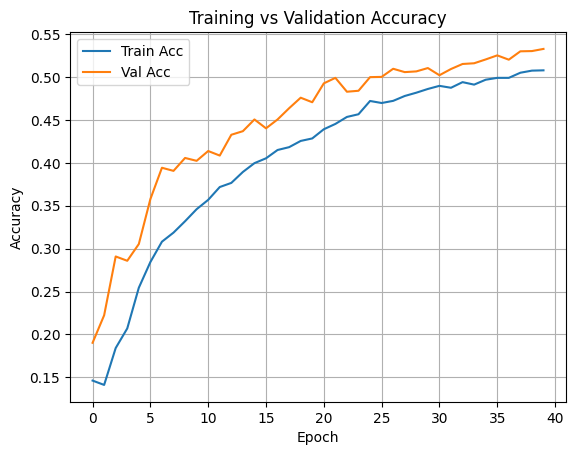

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.5395 - loss: 1.2295

✅ Final Validation Accuracy: 0.5302
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step


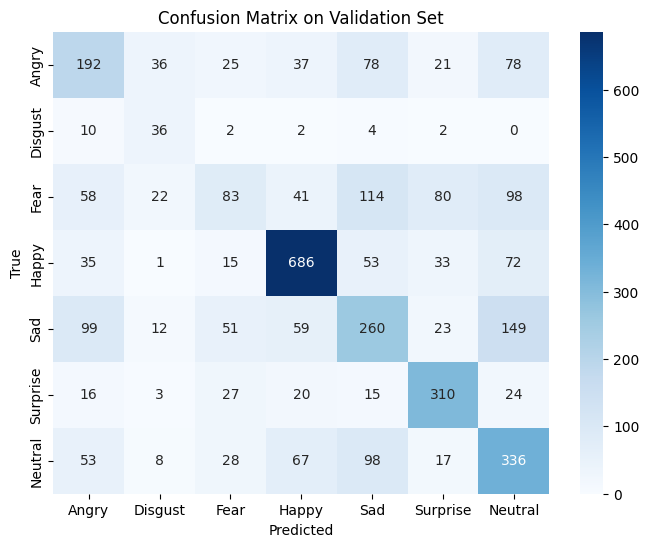

In [1]:

!pip install -q tensorflow pandas numpy seaborn scikit-image opencv-python-headless


import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


df = pd.read_csv('/kaggle/input/fer2013/fer2013.csv')
df['pixels'] = df['pixels'].apply(lambda x: np.fromstring(x, sep=' '))
df = df[df['pixels'].apply(lambda x: len(x) == 48 * 48)]


train_df = df[df['Usage'] == 'Training']
val_df   = df[df['Usage'] == 'PublicTest']
test_df  = df[df['Usage'] == 'PrivateTest']

def preprocess(img_1d):
    img = img_1d.reshape(48, 48).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)

def prepare_data(df):
    X = np.stack(df['pixels'].values)
    X = np.array([preprocess(img) for img in X])
    X = X.astype('float32') / 255.0
    X = X.reshape(-1, 48, 48, 1)
    y_raw = df['emotion'].values
    y = to_categorical(y_raw, num_classes=7)
    return X, y, y_raw

X_train, y_train, y_raw_train = prepare_data(train_df)
X_val, y_val, y_raw_val = prepare_data(val_df)
X_test, y_test, y_raw_test = prepare_data(test_df)


class_weights = compute_class_weight('balanced', classes=np.unique(y_raw_train), y=y_raw_train)
class_weights = dict(enumerate(class_weights))


model = Sequential([
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=40,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"\n Final Validation Accuracy: {val_acc:.4f}")


y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Validation Set')
plt.show()
